# Persistence Analysis

This notebook analyzes the persistence (autocorrelation) of excess bond returns and macroeconomic predictors. It compares overlapping versus non-overlapping return specifications, as well as revised versus real-time macroeconomic data, to formalize the discussion around persistence and validation set leakage.

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils.base_utils as bu
from utils.forecast_vintages import ForecastVintageMacroStore

sns.set_theme(style='whitegrid', context='talk')

## 1. Persistence of Excess Bond Returns

First, we analyze the autocorrelation function (ACF) of both overlapping (annual) and non-overlapping (monthly) excess returns.

In [8]:
start_date = '1984-01-31'
end_date = '2025-06-30'
MATURITIES = ['24', '36', '48', '60', '84', '120']
maturities_all = [str(i) for i in range(12, 121) if i % 12 == 0]

# Load KR yields
yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities_all)
monthly_yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)])

# Annual overlapping excess returns
xr = bu.get_excess_returns(yields, horizon=12).dropna()

# Monthly non-overlapping excess returns
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna()

print("AR(1) coefficients for overlapping annual returns:")
print(xr[MATURITIES].apply(lambda x: x.autocorr(), axis=0))

print("\nAR(1) coefficients for non-overlapping monthly returns:")
print(monthly_xr[MATURITIES].apply(lambda x: x.autocorr(), axis=0))

AR(1) coefficients for overlapping annual returns:
24     0.960574
36     0.950286
48     0.941787
60     0.935165
84     0.925353
120    0.917895
dtype: float64

AR(1) coefficients for non-overlapping monthly returns:
24     0.213342
36     0.169026
48     0.131394
60     0.113521
84     0.080487
120    0.066973
dtype: float64


## 2. Persistence of Macroeconomic Data: Revised vs. Real-Time

We compare the persistence (AR(1) coefficients) of variables between a fully revised FRED-MD dataset and real-time vintages.

In [9]:
fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
# Load revised FRED-MD data
fred_md_revised = bu.get_fred_data('data/2026-01-MD.csv', start=fred_md_start_date, end=end_date)

# Calculate autocorrelation for revised macro series
revised_acf = fred_md_revised.apply(lambda x: x.autocorr(), axis=0)

print("Top 10 most persistent series in revised data:")
print(revised_acf.nlargest(10))
print("\nSummary statistics of AR(1) across all revised series:")
print(revised_acf.describe())

Top 10 most persistent series in revised data:
PERMIT      0.985904
BAAFFM      0.984631
AAAFFM      0.984358
PERMITS     0.979394
T10YFFM     0.976826
PERMITW     0.970379
HOUST       0.970088
T5YFFM      0.964911
PERMITMW    0.963660
HOUSTS      0.948172
dtype: float64

Summary statistics of AR(1) across all revised series:
count    126.000000
mean       0.145320
std        0.453567
min       -0.615602
25%       -0.182339
50%        0.075854
75%        0.418750
max        0.985904
dtype: float64


Let's iterate over a set of real-time vintages to compute the persistence of the real-time time series at various points in time, revealing whether the look-ahead bias from revisions changes the apparent persistence of the series.

Mean real-time AR(1) coefficients over vintages:
count    124.000000
mean       0.137277
std        0.491818
min       -0.648656
25%       -0.266678
50%       -0.000904
75%        0.556609
max        0.982599
dtype: float64


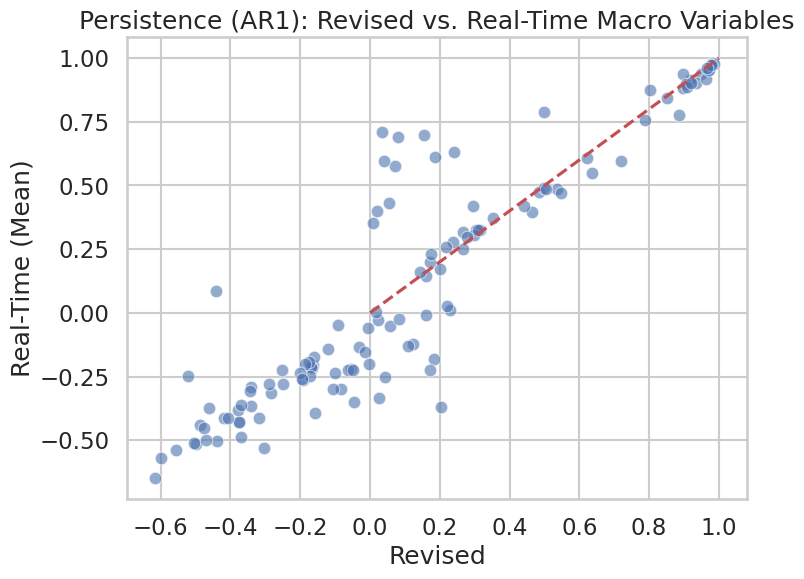

In [10]:
# Example: compare across different real-time evaluation points
eval_dates = pd.date_range(start='2000-01-31', end='2018-12-31', freq='YE')
realtime_acf_list = []

store = ForecastVintageMacroStore()

for d in eval_dates:
    panel = store.panel_for_forecast_date(d, start=start_date)
    fred_rt = panel.transformed
    rt_acf = fred_rt.apply(lambda x: x.autocorr(), axis=0)
    realtime_acf_list.append(rt_acf)

if realtime_acf_list:
    realtime_acf_df = pd.concat(realtime_acf_list, axis=1, keys=eval_dates)
    mean_realtime_acf = realtime_acf_df.mean(axis=1)
    
    print("Mean real-time AR(1) coefficients over vintages:")
    print(mean_realtime_acf.describe())
    
    # Comparison plot
    # Align the indices before plotting to make sure we compare the same series
    comparison = pd.DataFrame({'Revised': revised_acf, 'Real-Time (Mean)': mean_realtime_acf}).dropna()
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=comparison, x='Revised', y='Real-Time (Mean)', alpha=0.6)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.title('Persistence (AR1): Revised vs. Real-Time Macro Variables')
    plt.show()
else:
    print("Could not run vintage evaluation. Please verify ALFRED real-time setup.")